In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os

# Getting NIST data

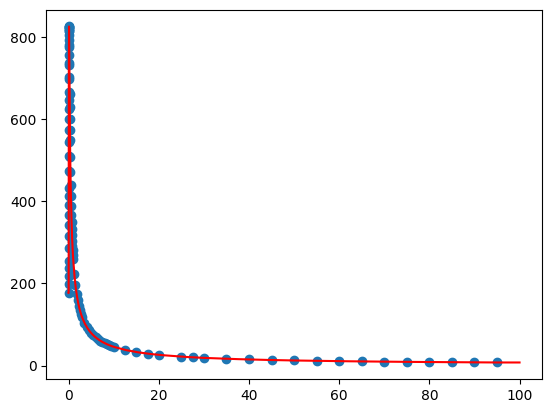

In [2]:
#Load in NIST SP data for protons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata['CSDA'] = data.iloc[:,2]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])
Expanded_SP['CSDA'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['CSDA'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP['Energy'], Expanded_SP['SP'], label='Interpolation', color='r')

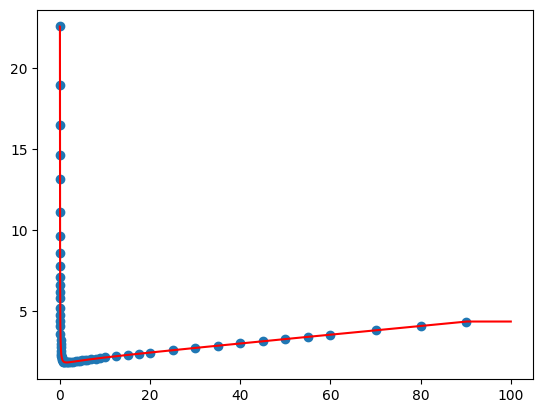

In [3]:
#Load in NIST SP data for electrons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power electrons.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP_el = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP_el['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP_el['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP_el['Energy'], Expanded_SP_el['SP'], label='Interpolation', color='r')

# Reading in each particle phsp to calculate LET

In [4]:
def Calculate_LET_from_phsp(phsp_path, NIST_data, NIST_data_el):
    try:
        #Read in phsp file
        d = pd.read_csv(phsp_path, header=None, sep='\s+')

        #Select protons
        d_p = d.loc[d.iloc[:,7]==2212]
        d_p.reset_index(inplace=True)

        proton_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        proton_data['Energy'] = d_p.iloc[:,6]
        proton_data['Weight'] = d_p.iloc[:,7]

        #Look up stopping power for each kinetic energy
        for i in range(len(proton_data)):
            en = proton_data.loc[i, 'Energy']

            sp = NIST_data[round(NIST_data['Energy'],4)==round(en,4)]
            
            #convert to LET
            proton_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]


        #Select electrons
        d_e = d.loc[d.iloc[:,7]==11]
        d_e.reset_index(inplace=True)

        el_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        el_data['Energy'] = d_e.iloc[:,6]
        el_data['Weight'] = d_e.iloc[:,7]
        

        #Look up stopping power for each kinetic energy
        for i in range(len(el_data)):
            en = float(el_data.loc[i, 'Energy'])

            sp = NIST_data_el[round(NIST_data_el['Energy'],4)==round(en,4)]
            
            #convert to LET
            el_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]
        
        particle_data = pd.concat([proton_data, el_data])

        mean_LET = round(particle_data['LET'].mean(),2)
        median_LET = round(particle_data['LET'].median(),2)

        #compute dose
        particle_data['Weight'] = particle_data['Weight']/len(particle_data)
        particle_data['Dose'] = particle_data['Weight']*particle_data['LET']

        dose = 1.602e-13*particle_data['Dose'].sum()
        
        
    except pd.errors.EmptyDataError:
        print('No histories for ' + phsp_path)

        mean_LET = 0
        median_LET = 0
        dose = 0

    print(phsp_path + ' finished')

    return mean_LET, median_LET, dose

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\linux\AppData\Local\Temp\ipykernel_5912\2928529480.py:4: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv(phsp_path, header=None, sep='\s+')


In [5]:
dir = r"..\TOPAS_data\do_field"
list = os.listdir(dir)

topas_let = pd.DataFrame(columns=['Depth', 'Mean LET', 'Median LET', 'Dose'])
for file in list:
    if os.path.splitext(file)[-1] == '.phsp':
        newrow = {}
        newrow['Depth'] = float(os.path.splitext(file)[0])
        newrow['Mean LET'], newrow['Median LET'], newrow['Dose'] = Calculate_LET_from_phsp(os.path.join(dir,file), Expanded_SP, Expanded_SP_el)

        newrow = pd.DataFrame([newrow])
        topas_let = pd.concat([topas_let, newrow], ignore_index=True)

topas_let = topas_let.sort_values(by='Depth')
print(topas_let)

..\TOPAS_data\do_field\0.phsp finished


C:\Users\linux\AppData\Local\Temp\ipykernel_5912\4182577031.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  topas_let = pd.concat([topas_let, newrow], ignore_index=True)


..\TOPAS_data\do_field\10.phsp finished
..\TOPAS_data\do_field\20.phsp finished
..\TOPAS_data\do_field\30.phsp finished
..\TOPAS_data\do_field\32.phsp finished
..\TOPAS_data\do_field\33.phsp finished
..\TOPAS_data\do_field\34.phsp finished
..\TOPAS_data\do_field\35.5.phsp finished
..\TOPAS_data\do_field\35.phsp finished
..\TOPAS_data\do_field\36.5.phsp finished
..\TOPAS_data\do_field\36.phsp finished
..\TOPAS_data\do_field\37.5.phsp finished
..\TOPAS_data\do_field\37.phsp finished
..\TOPAS_data\do_field\38.5.phsp finished
..\TOPAS_data\do_field\38.phsp finished
..\TOPAS_data\do_field\39.5.phsp finished
..\TOPAS_data\do_field\39.phsp finished
..\TOPAS_data\do_field\40.5.phsp finished
..\TOPAS_data\do_field\40.phsp finished
..\TOPAS_data\do_field\41.5.phsp finished
..\TOPAS_data\do_field\41.phsp finished
..\TOPAS_data\do_field\42.5.phsp finished
..\TOPAS_data\do_field\42.phsp finished
..\TOPAS_data\do_field\43.5.phsp finished
..\TOPAS_data\do_field\43.phsp finished
..\TOPAS_data\do_field

Text(0.5, 1.0, 'LET as function of depth')

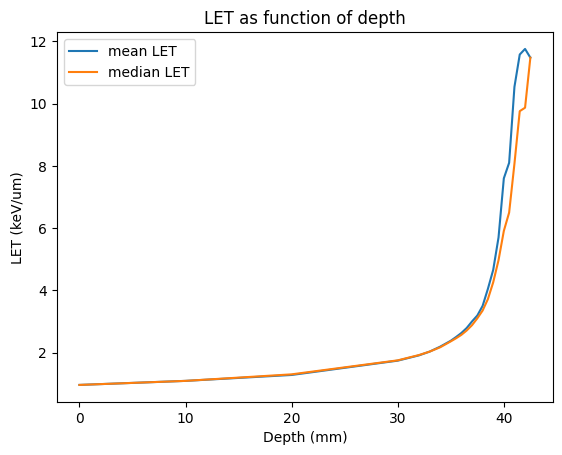

In [6]:
plt.plot(topas_let['Depth'], topas_let['Mean LET'], label='mean LET')
plt.plot(topas_let['Depth'], topas_let['Median LET'], label='median LET')
plt.legend()
plt.xlabel('Depth (mm)')
plt.ylabel('LET (keV/um)')
plt.title('LET as function of depth')

In [12]:
print(topas_let)

    Depth  Mean LET  Median LET          Dose
0     0.0      0.96        0.96  1.544521e-13
1    10.0      1.09        1.09  1.743597e-13
2    20.0      1.28        1.30  2.051338e-13
3    30.0      1.74        1.75  2.783962e-13
4    32.0      1.91        1.92  3.063110e-13
5    33.0      2.03        2.03  3.257744e-13
6    34.0      2.19        2.17  3.501886e-13
8    35.0      2.38        2.36  3.818467e-13
7    35.5      2.50        2.46  4.009379e-13
10   36.0      2.63        2.57  4.217756e-13
9    36.5      2.79        2.71  4.473281e-13
12   37.0      3.00        2.88  4.813489e-13
11   37.5      3.19        3.10  5.106951e-13
14   38.0      3.50        3.35  5.609279e-13
13   38.5      4.05        3.72  6.489074e-13
16   39.0      4.66        4.26  7.462084e-13
15   39.5      5.70        4.97  9.123732e-13
18   40.0      7.60        5.91  1.217771e-12
17   40.5      8.10        6.50  1.297990e-12
20   41.0     10.54        8.07  1.687866e-12
19   41.5     11.58        9.76  1

Text(0.5, 1.0, 'Dose as function of depth')

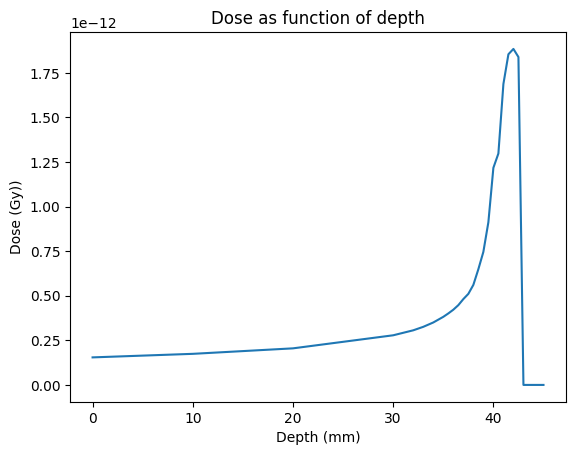

In [7]:
plt.plot(topas_let['Depth'], topas_let['Dose'])
plt.xlabel('Depth (mm)')
plt.ylabel('Dose (Gy))')
plt.title('Dose as function of depth')

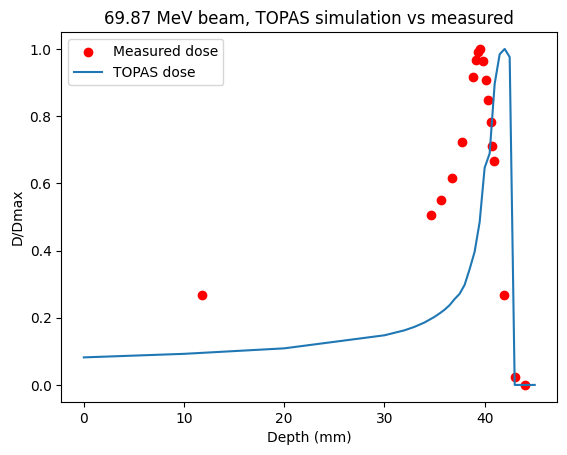

In [11]:
data = pd.read_excel(r"../Mid LET calculation/BP 69.87 measured - copy for scripts.xlsx")

BP_measured = pd.DataFrame()
BP_measured['Depth'] = data['Depth (mm)']
BP_measured['Dose'] = data['Dose (Gy)']/np.max(data['Dose (Gy)'])

plt.scatter(BP_measured['Depth'], BP_measured['Dose'], label='Measured dose', color='r')
plt.plot(topas_let['Depth'], topas_let['Dose']/max(topas_let['Dose']), label = 'TOPAS dose')
plt.title('69.87 MeV beam, TOPAS simulation vs measured')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax')
plt.legend()

In [ ]:
dir = r"..\TOPAS_data\do_field\Dose"
list = os.listdir(dir)

topas_dose = pd.DataFrame(columns=['Depth', 'Dose'])
for file in list:
    newrow = {}
    newrow['Depth'] = float(os.path.splitext(file)[0])
    newrow['Dose'] = pd.read_csv(os.path.join(dir,file), skiprows=5, header=None).iloc[0][0]

    newrow = pd.DataFrame([newrow])
    topas_dose = pd.concat([topas_dose, newrow], ignore_index=True)

#normalise dose
topas_dose['Dose_norm'] = topas_dose['Dose']/max(topas_dose['Dose'])

In [ ]:
plt.scatter(BP_measured['Depth'], BP_measured['Dose'], label='Measured dose', color='r')
plt.plot(topas_dose['Depth'], topas_dose['Dose_norm'], label = 'TOPAS dose')
plt.title('69.87 MeV beam, TOPAS simulation vs measured')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax')
plt.legend()